# Anderson Mao: Numerical Box-Size Convergence

This notebook covers Anderson's assigned contribution: testing how the finite numerical box affects the lowest six one-dimensional quantum harmonic-oscillator states. It imports the canonical functions from qho_project.py so that the Hamiltonian, boundary condition, eigensolver, and normalization exactly match the final team code.

In [1]:
import numpy as np
import pandas as pd

from qho_project import QHOConfig, box_size_study, plot_box_convergence

pd.set_option("display.precision", 10)

## Method

The true oscillator extends over the entire real line, but the numerical calculation uses \(x\in[-L,L]\) with Dirichlet conditions \(\psi(-L)=\psi(L)=0\). To isolate box-size error from grid-spacing error, this study holds
\[
\Delta x = 0.02
\]
fixed while increasing \(L\). For each half-width, the full-grid size is selected with
\[
N = \operatorname{round}(2L/\Delta x)+1.
\]
We monitor both \(|E_n(L)-E_n(L=8)|\) and the wavefunction amplitude at the first interior point next to either boundary. The latter is more informative than checking the endpoints themselves, which are exactly zero by construction.

In [2]:
config = QHOConfig(
    half_width=8.0,
    grid_points=1000,
    num_states=6,
)
half_widths = (2.5, 3.0, 3.5, 4.0, 5.0, 6.0, 7.0, 8.0)
study = box_size_study(
    config,
    half_widths=half_widths,
    target_dx=0.02,
)

study[[
    "L",
    "N",
    "dx",
    "max_change_from_largest_box",
    "max_near_boundary_amplitude",
]]

,L,N,dx,max_change_from_largest_box,max_near_boundary_amplitude
0,2.5,251,0.02,2.6508017353e+00,4.3833431541e-02
1,3.0,301,0.02,9.7240390519e-01,2.9623848302e-02
2,3.5,351,0.02,2.5842435682e-01,1.7975522184e-02
3,4.0,401,0.02,3.9376605129e-02,8.3890350557e-03
4,5.0,501,0.02,9.8652424990e-05,5.4230431489e-04
5,6.0,601,0.02,1.5764342720e-08,7.9417186891e-06
6,7.0,701,0.02,2.1938006967e-13,3.3250562905e-08
7,8.0,801,0.02,0.0000000000e+00,4.3682012257e-11


The highest included state, \(n=5\), is spatially widest and therefore provides the most demanding boundary test.

In [3]:
study[[
    "L",
    "energy_0",
    "energy_5",
    "absolute_error_5",
    "change_from_largest_box_5",
    "near_boundary_amplitude_5",
]]

,L,energy_0,energy_5,absolute_error_5,change_from_largest_box_5,near_boundary_amplitude_5
0,2.5,0.5049423532,8.1500391287,2.6500391287,2.6508017353e+00,4.3833431541e-02
1,3.0,0.5003787512,6.4716412986,0.9716412986,9.7240390519e-01,2.9623848302e-02
2,3.5,0.5000055612,5.7576617502,0.2576617502,2.5842435682e-01,1.7975522184e-02
3,4.0,0.4999879914,5.5386139985,0.0386139985,3.9376605129e-02,8.3890350557e-03
4,5.0,0.4999874998,5.4993360458,0.0006639542,9.8652424990e-05,5.4230431489e-04
5,6.0,0.4999874997,5.4992374092,0.0007625908,1.5764342720e-08,7.9417186891e-06
6,7.0,0.4999874997,5.4992373934,0.0007626066,2.1938006967e-13,3.3250562905e-08
7,8.0,0.4999874997,5.4992373934,0.0007626066,0.0000000000e+00,4.3682012257e-11


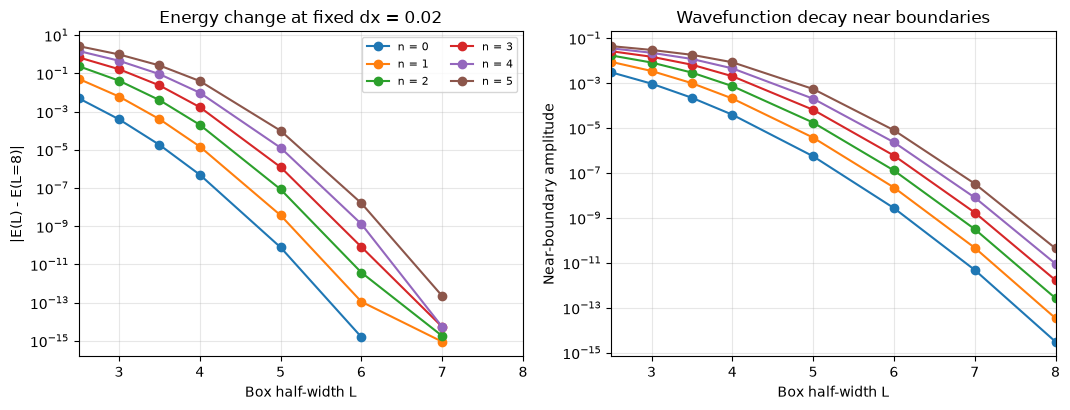

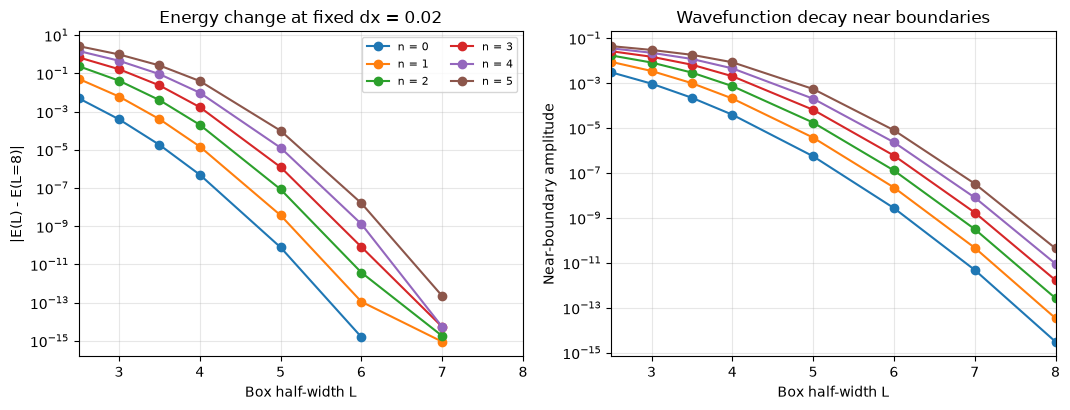

In [4]:
figure = plot_box_convergence(study, config.num_states)
figure

In [5]:
energy_columns = [f"energy_{state}" for state in range(config.num_states)]
energies = study[energy_columns].to_numpy()
index_l6 = int(np.flatnonzero(np.isclose(study["L"], 6.0))[0])
index_l7 = int(np.flatnonzero(np.isclose(study["L"], 7.0))[0])
index_l8 = int(np.flatnonzero(np.isclose(study["L"], 8.0))[0])

change_l6_l8 = np.max(np.abs(energies[index_l6] - energies[index_l8]))
change_l7_l8 = np.max(np.abs(energies[index_l7] - energies[index_l8]))
boundary_l8 = study.loc[index_l8, "max_near_boundary_amplitude"]

print(f"Maximum L=6 to L=8 energy change: {change_l6_l8:.3e}")
print(f"Maximum L=7 to L=8 energy change: {change_l7_l8:.3e}")
print(f"Largest near-boundary amplitude at L=8: {boundary_l8:.3e}")

assert np.ptp(study["dx"].to_numpy()) < 1e-12
assert change_l7_l8 < 1e-8
assert boundary_l8 < 1e-8

Maximum L=6 to L=8 energy change: 1.576e-08
Maximum L=7 to L=8 energy change: 2.194e-13
Largest near-boundary amplitude at L=8: 4.368e-11


## Result

The small boxes strongly confine the wider excited states. At \(L=2.5\), the \(n=5\) energy is approximately \(8.15\), far above the analytic value \(5.5\), and its near-boundary amplitude is about \(4.38\times10^{-2}\). As the box grows, both indicators rapidly decrease.

At \(L=6\), the largest energy change relative to \(L=8\) is \(1.58\times10^{-8}\). Between \(L=7\) and \(L=8\), the largest change is only \(2.19\times10^{-13}\), while the largest near-boundary amplitude at \(L=8\) is \(4.37\times10^{-11}\). The six requested states have therefore stabilized with respect to box size by the baseline choice \(L=8\).

The energy errors do not approach zero as \(L\) increases because \(\Delta x\) is intentionally held fixed. Once box error is negligible, the remaining plateau is the finite-difference discretization error measured separately by the grid-spacing study.

## References and Assistance

- MIT OpenCourseWare, [Lecture 13: Delta Function Potential, Node Theorem, and Simple Harmonic Oscillator](https://live.ocw.mit.edu/courses/8-04-quantum-physics-i-spring-2016/ff9fdba4da09b783255583e2a61d1279_MIT8_04S16_LecNotes13.pdf).
- SciPy, [scipy.sparse.linalg.eigsh documentation](https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.eigsh.html).
- OpenAI Codex assisted Anderson Mao with integrating the shared solver, implementing this convergence study, and drafting validation and explanatory text. Anderson and the team should review the final submission.